In [2]:
pip install tensorflow pandas numpy yfinance scikit-learn matplotlib ta-lib sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install TA_Lib-0.4.28-cp311-cp311-win_amd64.whl

Processing c:\users\dmlxo\documents\github\ai-stock\models\ta_lib-0.4.28-cp311-cp311-win_amd64.whl
TA-Lib is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib
import yfinance as yf
import datetime

# 한글 폰트 설정 (필요시)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# yfinance를 이용하여 애플 주식 데이터 다운로드 (2013~2023)
start_date = "2024-01-01"
end_date = "2024-12-31"
df = yf.download("AAPL", start=start_date, end=end_date)

# 데이터 인덱스는 날짜로 설정되어 있으므로 별도 변환 불필요
print(df.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-01-02  184.532074  187.315366  182.792518  186.033057  82488700
2024-01-03  183.150375  184.770652  182.335262  183.120556  58414500
2024-01-04  180.824356  181.997307  179.800504  181.062914  71983600
2024-01-05  180.098709  181.669281  179.094742  180.903888  62303300
2024-01-08  184.452560  184.492330  180.416793  181.003268  59144500


In [2]:
# C-contiguous 배열로 변환 및 1차원으로 평탄화(squeeze)
close = np.ascontiguousarray(np.squeeze(df['Close'].values), dtype=float)
high = np.ascontiguousarray(np.squeeze(df['High'].values), dtype=float)
low = np.ascontiguousarray(np.squeeze(df['Low'].values), dtype=float)
volume = np.ascontiguousarray(np.squeeze(df['Volume'].values), dtype=float)

In [3]:
### 2. TA‑LIB를 사용한 기술적 지표 계산
# 각 지표의 파라미터는 기본값 또는 예시값입니다.

In [4]:
# RSI (Relative Strength Index)
df['RSI'] = talib.RSI(close, timeperiod=14)

# MACD (Moving Average Convergence Divergence)
df['MACD'], df['MACD_Signal'], df['MACD_Hist'] = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)

# Stochastic Oscillator: SlowK, SlowD
df['SlowK'], df['SlowD'] = talib.STOCH(high, low, close,
                                        fastk_period=14, slowk_period=3, slowd_period=3)

# CCI (Commodity Channel Index)
df['CCI'] = talib.CCI(high, low, close, timeperiod=14)

# MFI (Money Flow Index)
df['MFI'] = talib.MFI(high, low, close, volume, timeperiod=14)

# ADX (Average Directional Index)
df['ADX'] = talib.ADX(high, low, close, timeperiod=14)

# SMA (Simple Moving Average)
df['SMA'] = talib.SMA(close, timeperiod=20)

# EMA (Exponential Moving Average)
df['EMA'] = talib.EMA(close, timeperiod=20)

# WMA (Weighted Moving Average)
df['WMA'] = talib.WMA(close, timeperiod=20)

# Bollinger Bands: Upper, Middle, Lower
df['UpperBand'], df['MiddleBand'], df['LowerBand'] = talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)

# SAR (Parabolic SAR)
df['SAR'] = talib.SAR(high, low, acceleration=0.02, maximum=0.2)

# ATR (Average True Range)
df['ATR'] = talib.ATR(high, low, close, timeperiod=14)

# NATR (Normalized ATR)
df['NATR'] = talib.NATR(high, low, close, timeperiod=14)

# TRANGE (True Range)
df['TRANGE'] = talib.TRANGE(high, low, close)

# OBV (On-Balance Volume)
df['OBV'] = talib.OBV(close, volume)

# AD (Accumulation/Distribution Line)
df['AD'] = talib.AD(high, low, close, volume)

# ADOSC (Chaikin A/D Oscillator)
df['ADOSC'] = talib.ADOSC(high, low, close, volume, fastperiod=3, slowperiod=10)

print(df.tail())

Price            Close        High         Low        Open    Volume  \
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL   
Date                                                                   
2024-12-23  254.989655  255.369227  253.171646  254.490204  40858800   
2024-12-24  257.916443  257.926411  255.009620  255.209412  23234700   
2024-12-26  258.735504  259.814335  257.347047  257.906429  27237100   
2024-12-27  255.309296  258.415896  252.782075  257.546826  42355300   
2024-12-30  251.923019  253.221595  250.474615  251.952985  35557500   

Price             RSI      MACD MACD_Signal MACD_Hist      SlowK  ...  \
Ticker                                                            ...   
Date                                                              ...   
2024-12-23  73.085636  5.765470    5.220889  0.544581  89.322287  ...   
2024-12-24  75.750268  6.067327    5.390177  0.677150  98.044297  ...   
2024-12-26  76.452857  6.300019    5.572145  0.727874  97.

## 3. 지표 시각화 예제
### 캔들 차트 위에 SMA, EMA, 볼린저 밴드를 그리고, 별도의 서브플롯에 RSI와 MACD를 그려봅니다.

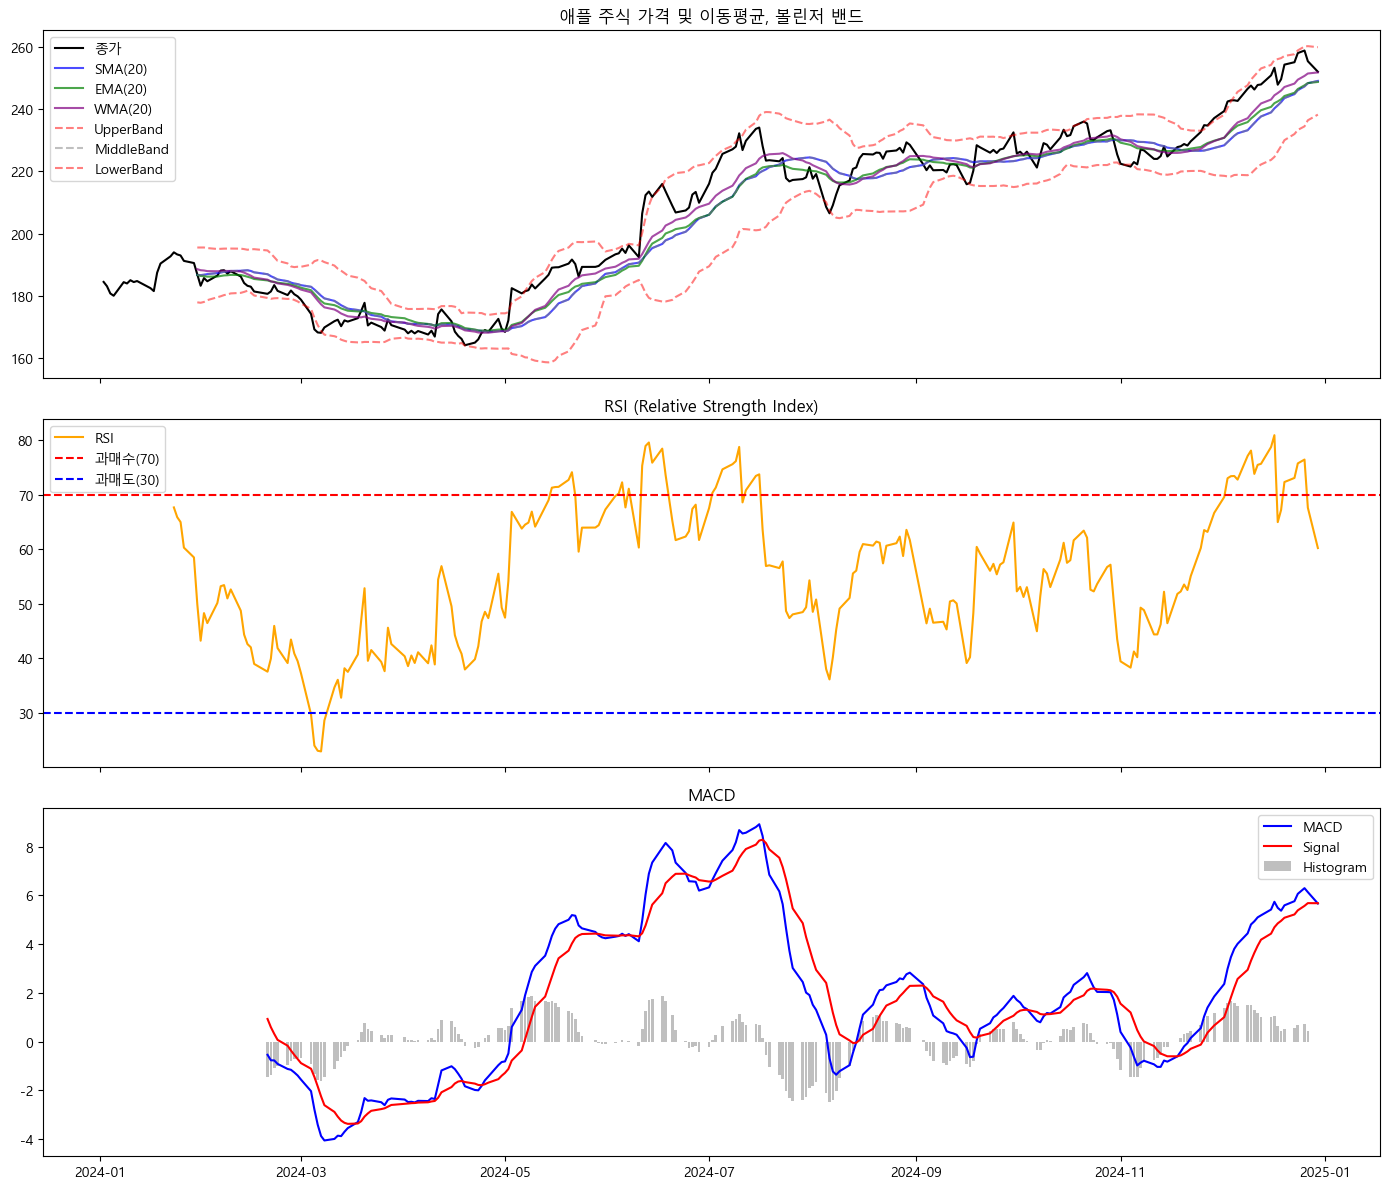

In [5]:
# 메인 차트: 가격 및 이동평균선, 볼린저 밴드
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# 가격과 이동평균선
ax1.plot(df.index, df['Close'], label='종가', color='black')
ax1.plot(df.index, df['SMA'], label='SMA(20)', color='blue', alpha=0.7)
ax1.plot(df.index, df['EMA'], label='EMA(20)', color='green', alpha=0.7)
ax1.plot(df.index, df['WMA'], label='WMA(20)', color='purple', alpha=0.7)
# 볼린저 밴드
ax1.plot(df.index, df['UpperBand'], label='UpperBand', linestyle='--', color='red', alpha=0.5)
ax1.plot(df.index, df['MiddleBand'], label='MiddleBand', linestyle='--', color='gray', alpha=0.5)
ax1.plot(df.index, df['LowerBand'], label='LowerBand', linestyle='--', color='red', alpha=0.5)
ax1.set_title('애플 주식 가격 및 이동평균, 볼린저 밴드')
ax1.legend()

# RSI 서브플롯
ax2.plot(df.index, df['RSI'], label='RSI', color='orange')
ax2.axhline(70, color='red', linestyle='--', label='과매수(70)')
ax2.axhline(30, color='blue', linestyle='--', label='과매도(30)')
ax2.set_title('RSI (Relative Strength Index)')
ax2.legend()

# MACD 서브플롯
ax3.plot(df.index, df['MACD'], label='MACD', color='blue')
ax3.plot(df.index, df['MACD_Signal'], label='Signal', color='red')
ax3.bar(df.index, df['MACD_Hist'], label='Histogram', color='gray', alpha=0.5)
ax3.set_title('MACD')
ax3.legend()

plt.tight_layout()
plt.show()

## 4. 고점/저점 판단 및 매수/매도 시점 결정

### 예제 조건:
### - RSI가 30 미만일 때 과매도 상태 → 매수 시그널 후보
### - RSI가 70 초과일 때 과매수 상태 → 매도 시그널 후보
### - MACD 히스토그램의 변화(양에서 음, 음에서 양)가 추세 전환의 신호가 될 수 있음

### 아래는 간단한 조건으로 매수, 매도 시그널을 결정하는 예시입니다.


In [6]:
df['Signal'] = 0  # 0: 관망, 1: 매수, -1: 매도

# 단순한 조건: RSI와 MACD 히스토그램 크로스오버
for i in range(1, len(df)):
    # 과매도 & MACD 히스토그램 양전환 → 매수 시그널
    if (df['RSI'].iloc[i] < 30) and (df['MACD_Hist'].iloc[i-1] < 0 and df['MACD_Hist'].iloc[i] > 0):
        df['Signal'].iloc[i] = 1
    # 과매수 & MACD 히스토그램 음전환 → 매도 시그널
    elif (df['RSI'].iloc[i] > 70) and (df['MACD_Hist'].iloc[i-1] > 0 and df['MACD_Hist'].iloc[i] < 0):
        df['Signal'].iloc[i] = -1

# Signal 발생 시점 확인
buy_signals = df[df['Signal'] == 1]
sell_signals = df[df['Signal'] == -1]

print("매수 시그널 발생일:\n", buy_signals.index)
print("매도 시그널 발생일:\n", sell_signals.index)


매수 시그널 발생일:
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None)
매도 시그널 발생일:
 DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None)


## 5. 매수/매도 시그널 시각화
### 캔들 차트 위에 매수(녹색)와 매도(빨간) 시그널을 표시합니다.

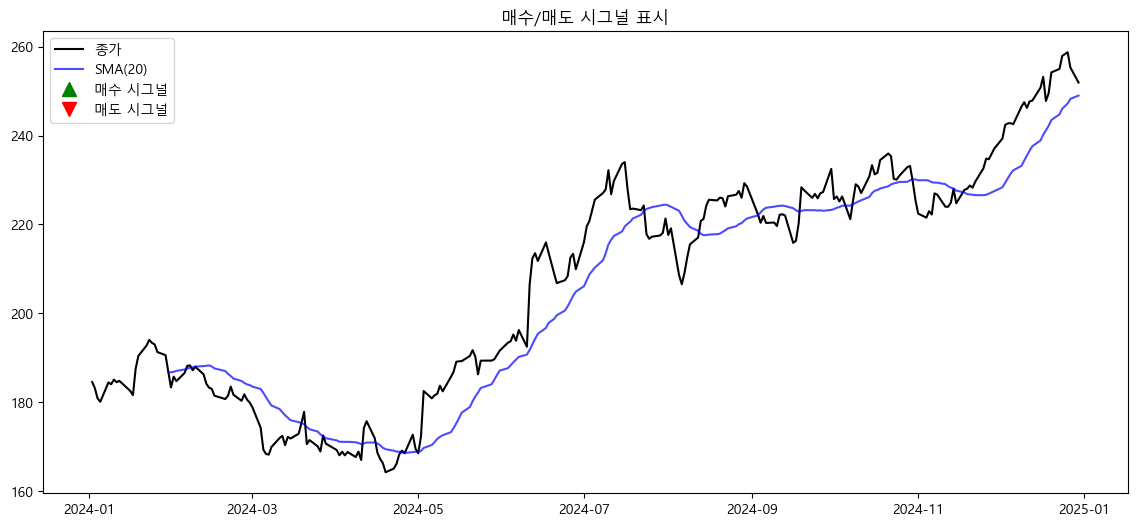

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df['Close'], label='종가', color='black')
ax.plot(df.index, df['SMA'], label='SMA(20)', color='blue', alpha=0.7)

# 매수 시그널
ax.plot(buy_signals.index, df.loc[buy_signals.index, 'Close'], '^', markersize=10, color='green', label='매수 시그널')
# 매도 시그널
ax.plot(sell_signals.index, df.loc[sell_signals.index, 'Close'], 'v', markersize=10, color='red', label='매도 시그널')

ax.set_title('매수/매도 시그널 표시')
ax.legend()
plt.show()

In [8]:
from sklearn.ensemble import RandomForestRegressor

# 3. 예측 목표(target) 생성: 다음 거래일의 종가
df['Target'] = df['Close'].shift(-1)

# 4. NA 제거 (지표 계산 시 시작부분이나 마지막 부분에 NA가 생길 수 있음)
df_model = df.dropna()

# 5. 특성(feature) 선택 (여기서는 예시로 주요 지표만 사용)
features = ['RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 
            'SlowK', 'SlowD', 'CCI', 'MFI', 'ADX',
            'SMA', 'EMA', 'WMA',
            'UpperBand', 'MiddleBand', 'LowerBand',
            'SAR', 'ATR', 'NATR', 'TRANGE', 'OBV', 'AD', 'ADOSC']

X = df_model[features]
y = df_model['Target']

# 6. 모델 학습: 전체 데이터를 학습에 사용 (실제 상황에서는 train/test 분할 필요)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# 학습 데이터에 대한 예측 성능 확인 (MAE)
pred_train = model.predict(X)
print("Train MAE:", mean_absolute_error(y, pred_train))

# 7. 2024년 1월 2일 예측
# 2024년 1월 2일의 가격 예측은 전일(2023-12-31)의 지표를 기반으로 예측합니다.
# 2023년 12월 31일의 데이터를 가져와 해당 날짜의 기술적 지표가 모델 학습 시 사용된 형식과 동일한지 확인
last_date = df.index[-1]
print("마지막 날짜:", last_date)

# 마지막 날짜의 특성 데이터를 사용
last_features = df.loc[last_date, features].values.reshape(1, -1)
predicted_price = model.predict(last_features)[0]
print("예측된 2024-01-02 종가:", predicted_price)


NameError: name 'mean_absolute_error' is not defined